In [ ]:
# --------------------------------------------------------------------------------------
# CELL 1: Setup and Data Access
# --------------------------------------------------------------------------------------
import os
import sys

# Install wfdb library (essential for MIT-BIH data)
!pip install --quiet wfdb

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Define the root directory for the ECG data
ECG_ROOT = "/content/drive/MyDrive/AI4BM/ECG_MITBIH" # Update this path if needed
print("ECG Data Root:", ECG_ROOT)

# --------------------------------------------------------------------------------------
# CELL 2: Imports and Configuration
# --------------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import glob
import wfdb
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.signal import butter, filtfilt

# Configuration constants
FS = 360 # MIT-BIH sampling frequency is typically 360 Hz
WINDOW_SIZE = 256 # Number of samples per segment (approx 0.71 seconds)
CLASSES = ['N', 'L', 'R', 'A', 'V'] # Common MIT-BIH beat annotations
# Mapping for Binary Classification: Normal (0) vs. Arrhythmia (1)
# N (Normal) -> 0
# All other beats (A, V, L, R, etc.) -> 1 (Arrhythmia/Non-Normal)
NORMAL_BEATS = ['N']
ARRHYTHMIA_BEATS = ['A', 'L', 'R', 'V', '/', 'E', 'J'] # Including common Non-N beats

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# --------------------------------------------------------------------------------------
# CELL 3: ECG Loader and Preprocessing Utilities
# --------------------------------------------------------------------------------------

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Applies a Butterworth bandpass filter for baseline wandering removal."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def load_and_segment_ecg(record_name, root_dir=ECG_ROOT, window_size=WINDOW_SIZE, fs=FS):
    """
    Loads ECG record, filters it, segments heartbeats around R-peaks,
    and assigns binary labels.
    """
    try:
        # Load the raw record signal and annotation
        record = wfdb.rdrecord(record_name, pn_dir='mitdb/', sampto=None, physical=True)
        annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb/')

        # We only use the first lead (MLII) for simplicity
        raw_signal = record.p_signal[:, 0]

        # 1. Baseline wander removal (0.5 to 40 Hz bandpass filter)
        filtered_signal = butter_bandpass_filter(raw_signal, 0.5, 40, fs)

        segments = []
        labels = []

        # 2. Segment around R-peaks
        qrs_indices = annotation.sample
        beat_types = annotation.symbol

        # Half window size for symmetric segmentation
        half_window = window_size // 2

        for r_idx, beat_type in zip(qrs_indices, beat_types):
            if beat_type in NORMAL_BEATS or beat_type in ARRHYTHMIA_BEATS:
                start = r_idx - half_window
                end = r_idx + half_window

                # Check for boundary conditions
                if start >= 0 and end <= len(filtered_signal):
                    segment = filtered_signal[start:end]

                    # Ensure segment has the correct length (e.g., handles rounding)
                    if len(segment) == window_size:
                        segments.append(segment)

                        # Assign binary label (0: Normal, 1: Arrhythmia)
                        label = 0 if beat_type in NORMAL_BEATS else 1
                        labels.append(label)

        return np.array(segments), np.array(labels)

    except Exception as e:
        print(f"Error processing record {record_name}: {e}")
        return np.empty((0, window_size)), np.empty((0,))


# --------------------------------------------------------------------------------------
# CELL 4: Build Dataset and Train/Test Split
# --------------------------------------------------------------------------------------

def build_ecg_dataset(root_dir):
    """
    Finds all records in the MIT-BIH directory and processes them.
    The MIT-BIH records are numbered 100-234 (some are excluded).
    """
    record_numbers = [
        '100', '101', '103', '105', '106', '108', '109', '112', '113', '114',
        '115', '116', '117', '118', '119', '121', '122', '123', '124', '200',
        '201', '202', '203', '205', '207', '208', '209', '210', '212', '213',
        '214', '215', '217', '219', '220', '221', '222', '223', '228', '230',
        '231', '232', '233', '234'
    ] # A standard subset of MIT-BIH records

    X_list, y_list = [], []
    print(f"Loading {len(record_numbers)} records...")

    # Temporarily change the working directory for wfdb to find the files
    # NOTE: Your files must be named like '100.dat', '100.hea' inside the ECG_ROOT
    original_cwd = os.getcwd()
    try:
        os.chdir(root_dir)
        for record_name in record_numbers:
            segments, labels = load_and_segment_ecg(record_name)
            if len(segments) > 0:
                X_list.append(segments)
                y_list.append(labels)
                print(f"  Loaded Record {record_name}: {len(segments)} segments.")
    finally:
        os.chdir(original_cwd) # Restore original working directory

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)

    # Reshape X for 1D CNN: (N_samples, Time_steps) -> (N_samples, Time_steps, 1)
    X_all = X_all[:, :, np.newaxis]

    print(f"\nTotal Segments Loaded: {len(X_all)}")

    # Split the dataset (80/10/10 split)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all, test_size=0.2, random_state=RANDOM_SEED, stratify=y_all
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
    )

    print(f"Train/Val/Test Shapes: {X_train.shape} / {X_val.shape} / {X_test.shape}")
    print(f"Train Class Distribution (0/1): {np.unique(y_train, return_counts=True)}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# Build the dataset
(X_train, y_train), (X_val, y_val), (X_test, y_test) = build_ecg_dataset(ECG_ROOT)


# --------------------------------------------------------------------------------------
# CELL 5: Scaling and PyTorch DataLoaders
# --------------------------------------------------------------------------------------

# Scaling: Since the signal is 3D (N, L, 1), we scale the signal across the length (L)
scaler = StandardScaler()
# Reshape for fitting: (N*L, 1)
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

class ECGDataset(Dataset):
    def __init__(self, X, y):
        # Transpose X to fit PyTorch Conv1D input: (N, Channels, Length) -> (N, 1, 256)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ECGDataset(X_train_scaled, y_train)
val_dataset = ECGDataset(X_val_scaled, y_val)
test_dataset = ECGDataset(X_test_scaled, y_test)

# Handle Imbalance using WeightedRandomSampler
class_counts = np.bincount(y_train)
print(f"Train Class Counts (0/1): {class_counts}")
weights_per_class = 1.0 / (class_counts + 1e-8)
sample_weights = weights_per_class[y_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# --------------------------------------------------------------------------------------
# CELL 6: 1D CNN Model and Training Loop
# --------------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
# The image below illustrates the segmentation process around the R-peak:
#

class ECG_CNN(nn.Module):
    def __init__(self, input_length=WINDOW_SIZE, in_channels=1, n_classes=2):
        super().__init__()

        self.conv_net = nn.Sequential(
            # Input: (Batch, 1, 256)
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Output length: 128

            nn.Conv1d(32, 64, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Output length: 64

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Output length: 32

            nn.Flatten()
        )
        # 128 channels * 32 length = 4096 features
        self.classifier = nn.Sequential(
            nn.Linear(128 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.conv_net(x)
        return self.classifier(x)

# Instantiate the model
model = ECG_CNN(input_length=WINDOW_SIZE).to(device)

# Compute class weights for loss (CrossEntropyLoss)
class_weights_tensor = torch.tensor(weights_per_class, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer and Scheduler setup
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            _, p = torch.max(logits, 1)
            preds.extend(p.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return np.array(preds), np.array(targets)

# Train loop
EPOCHS = 20
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    scheduler.step()
    train_loss = running_loss / total

    # Validation
    preds_val, targets_val = evaluate(model, val_loader, device)
    val_acc = accuracy_score(targets_val, preds_val)
    f1 = f1_score(targets_val, preds_val, average='binary', zero_division=0)

    print(f"Epoch {epoch}/{EPOCHS} | LR: {scheduler.get_last_lr()[0]:.6f} | Train Loss: {train_loss:.4f} "
          f"| Val Acc: {val_acc:.4f}, Val F1: {f1:.4f}")

# --------------------------------------------------------------------------------------
# CELL 7: Final Test Evaluation
# --------------------------------------------------------------------------------------

preds_test, targets_test = evaluate(model, test_loader, device)

print("\n===== FINAL TEST RESULTS =====")
print("Test Accuracy:", accuracy_score(targets_test, preds_test))
print("Precision:", precision_score(targets_test, preds_test, zero_division=0))
print("Recall:", recall_score(targets_test, preds_test, zero_division=0))
print("F1-score:", f1_score(targets_test, preds_test, zero_division=0))

print("\nConfusion Matrix (Test):\n", confusion_matrix(targets_test, preds_test))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 143.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
Mounted at /cont

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



--- Visualizing Final Metrics ---


<Figure size 600x600 with 0 Axes>

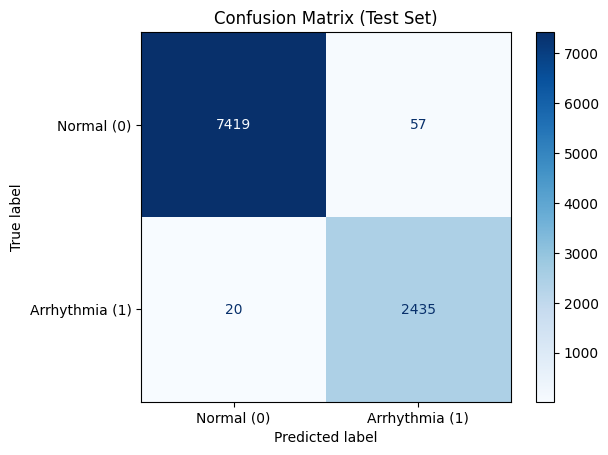

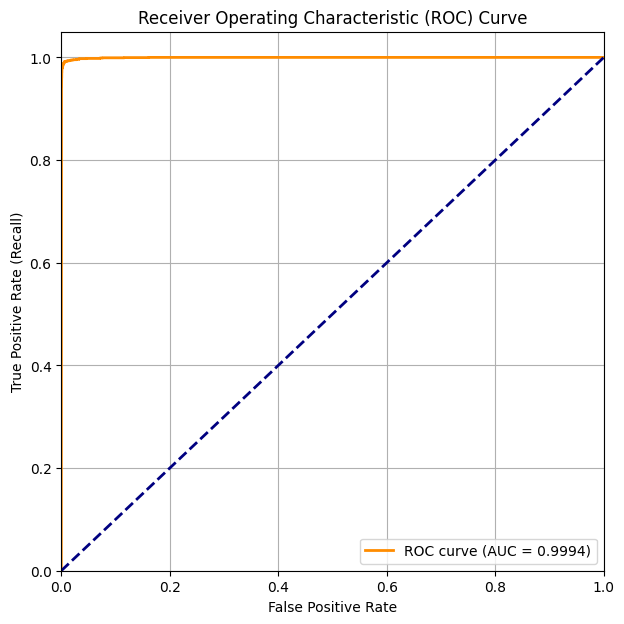

In [ ]:
# Cell 7 — Visualization of Confusion Matrix and ROC AUC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import torch.nn.functional as F

# The final metrics and arrays are used directly from the previous cell's execution:
# targets_test, preds_test (Binary Prediction)
# test_loader, model, device (for calculating probabilities)

# 1. Calculate raw prediction probabilities for the ROC AUC curve
def get_test_probs(model, loader, device):
    model.eval()
    all_logits = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            all_logits.append(logits.cpu().numpy())
    all_logits = np.concatenate(all_logits)
    # Get probability for the positive class (Arrhythmia, index 1)
    probs = F.softmax(torch.tensor(all_logits), dim=1)[:, 1].numpy()
    return probs

test_probs = get_test_probs(model, test_loader, device)

print("\n--- Visualizing Final Metrics ---")

# 2. Confusion Matrix Visualization
cm = confusion_matrix(targets_test, preds_test)
plt.figure(figsize=(6, 6))
# Labels for binary classification: 0=Normal, 1=Arrhythmia
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Arrhythmia (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# 3. ROC AUC Curve
fpr, tpr, thresholds = roc_curve(targets_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

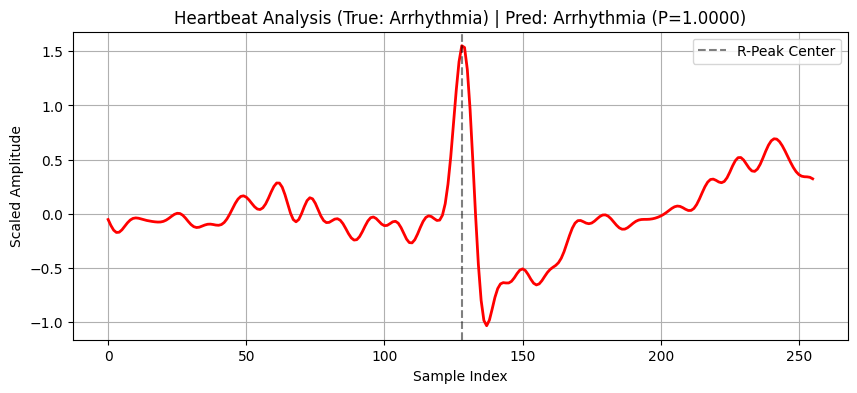

In [ ]:
# Cell 8 — Single Heartbeat Visualization (Qualitative Inference)
import wfdb
import matplotlib.pyplot as plt

# Get the first Arrhythmia sample from the test set for visualization
ARR_TEST_INDEX = np.where(y_test == 1)[0][0]

# Extract the raw, unscaled signal segment for plotting
# The shape is (N_samples, 1, 256), so we take [index, 0, :]
segment_scaled = X_test_scaled[ARR_TEST_INDEX, :, 0]

# Convert the scaled segment back to a PyTorch tensor, ready for inference
# Add batch dimension: (1, 256) -> (1, 1, 256)
X_single = torch.tensor(segment_scaled, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# 1. Perform inference on the single beat
model.eval()
with torch.no_grad():
    logits = model(X_single)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    prediction = np.argmax(probs)

# Determine the true and predicted labels
true_label = "Arrhythmia" if y_test[ARR_TEST_INDEX] == 1 else "Normal"
pred_label = "Arrhythmia" if prediction == 1 else "Normal"
prob_arrhythmia = probs[1]
color = 'red' if prediction == 1 else 'blue'

# 2. Plot the Heartbeat Segment
plt.figure(figsize=(10, 4))
plt.plot(segment_scaled, color=color, linewidth=2)
plt.title(
    f"Heartbeat Analysis (True: {true_label}) | Pred: {pred_label} (P={prob_arrhythmia:.4f})"
)
plt.xlabel("Sample Index")
plt.ylabel("Scaled Amplitude")
plt.grid(True)
plt.axvline(x=WINDOW_SIZE/2, color='k', linestyle='--', alpha=0.5, label='R-Peak Center')
plt.legend()
plt.show()

In [ ]:
# Cell 9 — Inference Speed Measurement
import time

NUM_WARMUP = 10  # Number of warm-up iterations
NUM_MEASURE = 100 # Number of batches to measure

# We assume test_loader, model, and device are defined and accessible

test_data_iter = iter(test_loader)

try:
    # --- 1. Warm-up Phase ---\
    model.eval()
    for _ in range(NUM_WARMUP):
        try:
            X_batch, _ = next(test_data_iter)
        except StopIteration:
            test_data_iter = iter(test_loader)
            X_batch, _ = next(test_data_iter)

        with torch.no_grad():
            _ = model(X_batch.to(device))

    # --- 2. Measurement Phase ---\
    start_time = time.time()
    total_windows_processed = 0

    for i in range(NUM_MEASURE):
        try:
            X_batch, _ = next(test_data_iter)
        except StopIteration:
            test_data_iter = iter(test_loader)
            X_batch, _ = next(test_data_iter)

        total_windows_processed += X_batch.shape[0]

        with torch.no_grad():
            _ = model(X_batch.to(device))

    end_time = time.time()

    # --- 3. Calculation and Reporting ---\
    total_time = (end_time - start_time) # Time in seconds
    avg_time_per_window_s = total_time / total_windows_processed
    avg_time_per_window_ms = avg_time_per_window_s * 1000

    print("\n===== INFERENCE SPEED RESULTS (ECG) =====")
    print(f"Total heartbeats processed: {total_windows_processed}")
    print(f"Total time measured: {total_time:.4f} seconds")
    print(f"Average inference speed per heartbeat: {avg_time_per_window_ms:.3f} ms")

    # Check against the 40 ms goal (40ms is 25 FPS)
    if avg_time_per_window_ms <= 40.0:
        print("\n✅ SUCCESS: Inference speed meets the 40 ms target.")
    else:
        print("\n⚠️ WARNING: Inference speed exceeds the 40 ms target.")
        print(f"Target: 40.0 ms | Exceeded by: {avg_time_per_window_ms - 40.0:.3f} ms")

    print("NOTE: Results are based on the current runtime (CPU/GPU) and may vary on target hardware.")

except Exception as e:
    print(f"An error occurred during timing: {e}")


===== INFERENCE SPEED RESULTS (ECG) =====
Total heartbeats processed: 6400
Total time measured: 0.1227 seconds
Average inference speed per heartbeat: 0.019 ms

✅ SUCCESS: Inference speed meets the 40 ms target.
NOTE: Results are based on the current runtime (CPU/GPU) and may vary on target hardware.


In [ ]:
# Save test set for orchestration notebook
# Run this once after training completes
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/AI4BM/ECG_MITBIH/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# X_test_scaled shape: (N, 256, 1) — already scaled, channels last
# y_test shape: (N,) — 0=Normal, 1=Arrhythmia
np.save(os.path.join(SAVE_DIR, "ecg_test.npy"),   X_test_scaled)
np.save(os.path.join(SAVE_DIR, "ecg_labels.npy"), y_test)

print(f"  ECG test set saved")
print(f"   X_test_scaled shape    : {X_test_scaled.shape}")
print(f"   y_test shape           : {y_test.shape}")
print(f"   Arrhythmia in test set : {int(y_test.sum())}")
print(f"   Normal in test set     : {int((y_test==0).sum())}")

  ECG test set saved
   X_test_scaled shape    : (9931, 256, 1)
   y_test shape           : (9931,)
   Arrhythmia in test set : 2455
   Normal in test set     : 7476
